In [26]:
!pip install smt


In [27]:
import numpy as np
from smt.sampling_methods import LHS
# Format: [Lower limit, Upper Limit]
limits=np.array([[1.0,5.0],[0.01,0.1],[100,1000]]) #length meter,thickness cm,load N/m
sampling=LHS(xlimits=limits)
num_points=200
x_train=sampling(num_points)
print("our 200 design combo(L,t,w):")
print(x_train)
L=x_train[:,0]
t=x_train[:,1]
w=x_train[:,2]
E=200e9 #youngs modulus for steel
b=0.2 #width of the beam in meters
#moment of inertia
I=(b*t**3)/12 #bt^cube/12
#maximum deflection
deflection=(w*L**4)/(8*E*I) #weight x L^4/8 times E xI
y_train=deflection.reshape(-1,1)
print("Our calculated deflections (y_train):")
print(y_train)

our 200 design combo(L,t,w):
[[1.2900e+00 7.5925e-02 8.9875e+02]
 [1.0300e+00 1.7425e-02 6.3775e+02]
 [2.3700e+00 4.9375e-02 8.0425e+02]
 [4.8500e+00 5.2075e-02 3.6325e+02]
 [3.2700e+00 2.5075e-02 6.0175e+02]
 [4.6500e+00 8.3575e-02 8.4925e+02]
 [4.1100e+00 6.8275e-02 2.2825e+02]
 [4.0100e+00 2.9125e-02 1.8775e+02]
 [3.9300e+00 2.7325e-02 8.1775e+02]
 [3.7900e+00 1.0225e-02 8.8525e+02]
 [3.2500e+00 7.6375e-02 9.3025e+02]
 [1.2700e+00 2.1475e-02 3.2275e+02]
 [4.7100e+00 5.7475e-02 9.7075e+02]
 [3.7100e+00 2.6875e-02 2.5075e+02]
 [4.6300e+00 4.9825e-02 2.5975e+02]
 [2.9100e+00 9.5275e-02 4.3975e+02]
 [1.7300e+00 1.8325e-02 5.4325e+02]
 [3.1500e+00 3.7225e-02 7.8625e+02]
 [2.0300e+00 6.0175e-02 7.5925e+02]
 [1.6100e+00 3.0475e-02 8.5375e+02]
 [4.1300e+00 9.3925e-02 3.5425e+02]
 [4.5900e+00 2.1025e-02 9.0775e+02]
 [2.1700e+00 6.5575e-02 8.0875e+02]
 [4.9700e+00 7.1425e-02 6.7825e+02]
 [2.7300e+00 2.8225e-02 1.2475e+02]
 [1.8300e+00 7.6825e-02 8.8075e+02]
 [1.0900e+00 4.1725e-02 9.5725e+02]

In [28]:
from smt.surrogate_models import KRG
sm=KRG(theta0=[1e-2]) #valur of theta0 is just a guess #initializing the kriging model
sm.set_training_values(x_train,y_train)
sm.train()
print("Model trained successfully")


___________________________________________________________________________
   
                                  Kriging
___________________________________________________________________________
   
 Problem size
   
      # training points.        : 200
   
___________________________________________________________________________
   
 Training
   
   Training ...
   Training - done. Time (sec): 22.5920956
Model trained successfully


___________________________________________________________________________
   
 Evaluation
   
      # eval points. : 50
   
   Predicting ...
   Predicting - done. Time (sec):  0.0062299
   
   Prediction time/pt. (sec) :  0.0001246
   


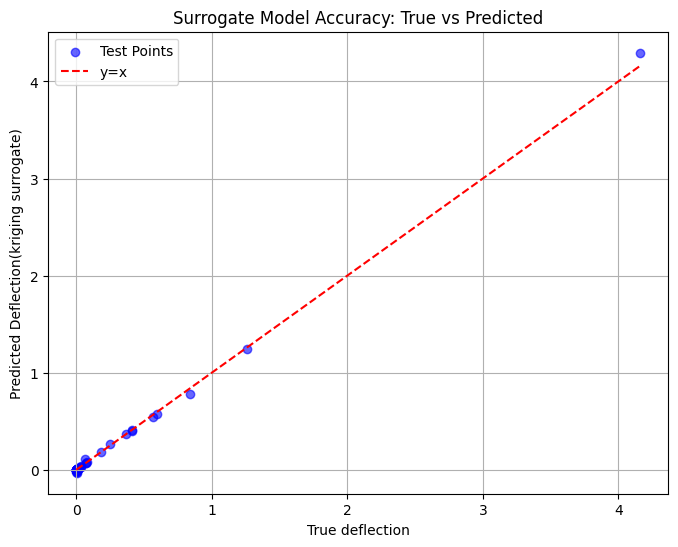

In [29]:
from matplotlib import figure
import matplotlib.pyplot as plt
#model testing
num_test_points=50
x_test=sampling(num_test_points)
L_test=x_test[:,0]
t_test=x_test[:,1]
w_test=x_test[:,2]
I_test=(b*t_test**3)/12
y_true=((w_test*L_test**4)/(8*E*I_test)).reshape(-1,1) #the real value
y_pred=sm.predict_values(x_test) #values predited by the model
plt.figure(figsize=(8,6))
plt.scatter(y_true,y_pred, color='blue',alpha=0.6,label='Test Points')
max_val=float(np.max(y_true))
min_val=float(np.min(y_true))
plt.plot([min_val,max_val],[min_val,max_val],'r--',label='y=x') #y=x line
plt.xlabel("True deflection")
plt.ylabel("Predicted Deflection(kriging surrogate)")
plt.title("Surrogate Model Accuracy: True vs Predicted")
plt.legend()
plt.grid(True)
plt.show()

In [30]:
from scipy.optimize import minimize
import numpy as np
#objective: minimize volume but in safety limit(constraint on deflection)
def obj(x):
  L=x[0]
  t=x[1]
  return L*b*t
def constraint(x):
  x_2d=np.array([x]).reshape(1,-1)
  pred_deflec=float(sm.predict_values(x_2d)[0][0])
  max_allowed=0.05
  return [max_allowed - pred_deflec,pred_deflec]
x_start=[2.0,0.05,500.0]
bounds=((1.0,10.0),(0.01,0.5),(500.0,500.0))
con={'type':'ineq','fun':constraint}
print("AI looking for optimal design...")
try:
  result= minimize(obj, x_start, method='SLSQP',bounds=bounds,constraints=con,options={'disp':True})
  print("\n Optimization result \n")
  print(f"Success status:{result.success}")
  print(f"Message:{result.message}")
  if result.success:
    print("The lightest safe design:")
    print(f"Optimal length(L):{result.x[0]:.3f} m")
    print(f"Optimal Thickness(t):{result.x[1]:.4f} m")
    finaldesign=np.array([result.x])
    finaldef=float(sm.predict_values(finaldesign)[0][0])
    print(f"Predicted Deflection:{finaldef:.4f}m")
  else:
    print("Optimization Failed")
except Exception as e:
  print(f"Error:{e}")


AI looking for optimal design...
___________________________________________________________________________
   
 Evaluation
   
      # eval points. : 1
   
   Predicting ...
   Predicting - done. Time (sec):  0.0007167
   
   Prediction time/pt. (sec) :  0.0007167
   
___________________________________________________________________________
   
 Evaluation
   
      # eval points. : 1
   
   Predicting ...
   Predicting - done. Time (sec):  0.0004809
   
   Prediction time/pt. (sec) :  0.0004809
   
___________________________________________________________________________
   
 Evaluation
   
      # eval points. : 1
   
   Predicting ...
   Predicting - done. Time (sec):  0.0004356
   
   Prediction time/pt. (sec) :  0.0004356
   
___________________________________________________________________________
   
 Evaluation
   
      # eval points. : 1
   
   Predicting ...
   Predicting - done. Time (sec):  0.0011261
   
   Prediction time/pt. (sec) :  0.0011261
   
_______________

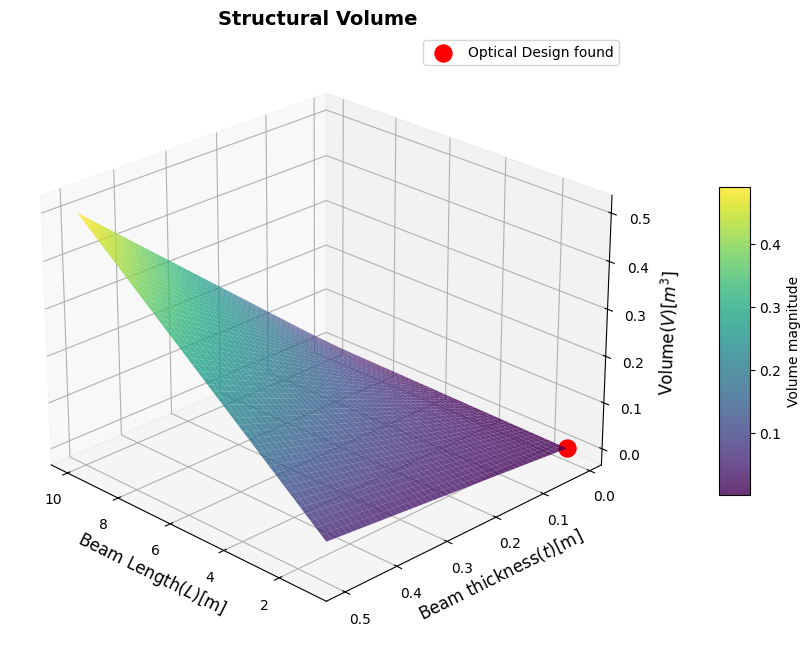

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
L_vals=np.linspace(1.0,10.0,50)
t_vals=np.linspace(0.01,0.5,50)
L_grid,t_grid=np.meshgrid(L_vals,t_vals)
b=0.1
V=L_grid*b*t_grid
fig=plt.figure(figsize=(12,8))
ax=fig.add_subplot(111,projection='3d')
surf=ax.plot_surface(L_grid,t_grid,V,cmap='viridis',edgecolor='none',alpha=0.8)
ax.scatter(1.0,0.01,0.001,color='red',s=150,label='Optical Design found',zorder=5)
ax.set_title('Structural Volume', fontsize=14,fontweight='bold')
ax.set_xlabel('Beam Length($L$)[m]',fontsize=12)
ax.set_ylabel('Beam thickness($t$)[m]',fontsize=12)
ax.set_zlabel('Volume($V$)[$m^3$]',fontsize=12)
fig.colorbar(surf,shrink=0.5,aspect=10,pad=0.1,label='Volume magnitude')
ax.view_init(elev=25,azim=135)
plt.legend()
plt.show()